# DTU 02443 Stochastic Simulation — Project 1
## Part 1, Task 1: Discrete-time Markov model of breast cancer

We follow women after breast-tumour removal. States:

1. No recurrence (start)
2. Local recurrence
3. Distant metastasis
4. Local recurrence **and** distant metastasis
5. Death (absorbing)

One time step = one month. We simulate **1000 women**, all starting in state 1, until death.
We then summarise the **lifetime distribution** (histogram) and report the **proportion of
women in whom the cancer reappears locally** (i.e. who ever visit state 2 or state 4).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import matrix_power
from scipy import stats

rng = np.random.default_rng(42)  # reproducibility

# Transition probability matrix P (rows = from-state, cols = to-state), states 1..5
P = np.array([
    [0.9915, 0.005 , 0.0025, 0.0  , 0.001],
    [0.0   , 0.986 , 0.005 , 0.004, 0.005],
    [0.0   , 0.0   , 0.992 , 0.003, 0.005],
    [0.0   , 0.0   , 0.0   , 0.991, 0.009],
    [0.0   , 0.0   , 0.0   , 0.0  , 1.0  ],
])

assert np.allclose(P.sum(axis=1), 1.0), "Rows of P must sum to 1"
print("Row sums:", P.sum(axis=1))

Row sums: [1. 1. 1. 1. 1.]


In [3]:
def simulate_woman(P, rng, start_state=1, death_state=5, max_steps=10000):
    """Simulate one woman until death.
    Returns (lifetime_in_months, visited_states_set). States are 1-indexed.
    Lifetime = number of transitions taken to reach death.
    """
    state = start_state
    visited = {state}
    t = 0
    while state != death_state and t < max_steps:
        state = rng.choice(5, p=P[state - 1]) + 1
        visited.add(state)
        t += 1
    return t, visited

N = 1000
lifetimes = np.empty(N, dtype=int)
local_recurrence = np.zeros(N, dtype=bool)   # ever entered state 2 or 4

for i in range(N):
    t, visited = simulate_woman(P, rng)
    lifetimes[i] = t
    local_recurrence[i] = (2 in visited) or (4 in visited)  # ever in a state with a local component

print(f"Simulated {N} women.")
print(f"Mean lifetime:   {lifetimes.mean():.2f} months ({lifetimes.mean()/12:.2f} years)")
print(f"Median lifetime: {np.median(lifetimes):.1f} months")
print(f"Std lifetime:    {lifetimes.std(ddof=1):.2f} months")
print(f"Min / Max:       {lifetimes.min()} / {lifetimes.max()} months")

Simulated 1000 women.
Mean lifetime:   260.29 months (21.69 years)
Median lifetime: 219.5 months
Std lifetime:    201.92 months
Min / Max:       1 / 1749 months


### Lifetime distribution

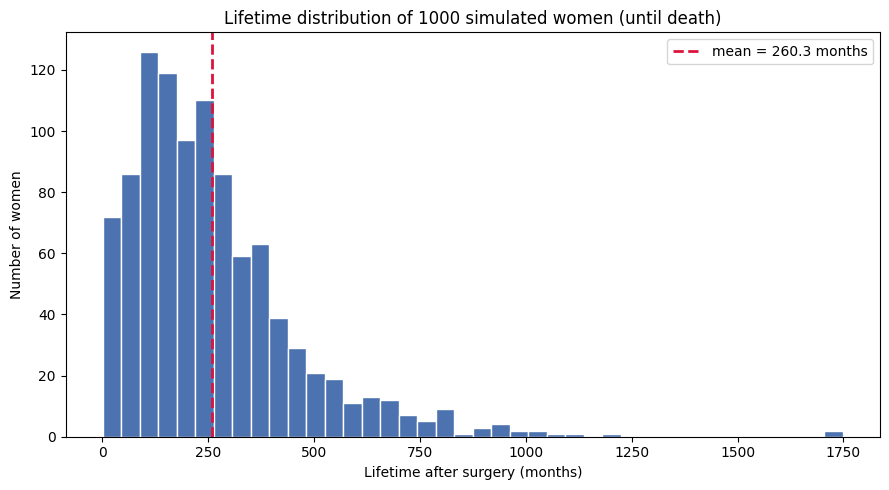

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(lifetimes, bins=40, color="#4C72B0", edgecolor="white")
ax.axvline(lifetimes.mean(), color="crimson", linestyle="--", linewidth=2,
           label=f"mean = {lifetimes.mean():.1f} months")
ax.set_xlabel("Lifetime after surgery (months)")
ax.set_ylabel("Number of women")
ax.set_title("Lifetime distribution of 1000 simulated women (until death)")
ax.legend()
plt.tight_layout()
plt.show()

### Proportion with local recurrence

A woman experiences a local recurrence if she ever enters **state 2 or state 4**. We give an
approximate 95% confidence interval for the proportion.

In [5]:
p_local = local_recurrence.mean()
se = np.sqrt(p_local * (1 - p_local) / N)
ci = (p_local - 1.96 * se, p_local + 1.96 * se)

print(f"Women with local recurrence: {local_recurrence.sum()} / {N}")
print(f"Proportion: {p_local:.4f}  ({100*p_local:.2f}%)")
print(f"Approx. 95% CI: [{ci[0]:.4f}, {ci[1]:.4f}]")

Women with local recurrence: 703 / 1000
Proportion: 0.7030  (70.30%)
Approx. 95% CI: [0.6747, 0.7313]


### Conclusion (Task 1)

- The lifetime distribution is right-skewed: most women survive many years (the absorbing
  death state is reached slowly), with a long tail.
- The mean lifetime after surgery is roughly **260 months (~21 years)**, consistent with the
  small per-month death probabilities.
- The cancer reappears **locally** (ever enters state 2 or state 4) in about **70%** of women.
  Here a woman counts as a local recurrence if she ever occupies a state that includes a local
  component (state 2, or state 4 = local + distant).

## Part 1, Task 2: State distribution at $t = 120$

The distribution over states at time $t$ can be computed analytically as
$$p_t = p_0\, P^{\,t}.$$
We compare this analytic distribution at $t = 120$ months against an empirical one obtained by
simulation, and test whether they agree using a Pearson $\chi^2$ goodness-of-fit test.

**Important:** dead women are *frozen* in state 5 rather than dropped, so all simulated women
are counted at exactly $t = 120$. This is what makes the empirical distribution comparable to
$p_0 P^{120}$, which also accumulates mass in the death state.

In [12]:
# --- Analytic distribution over states at t = 120 ---
p0 = np.array([1, 0, 0, 0, 0])
T = 120
p_theory = p0 @ matrix_power(P, T)

# --- Simulate the state at t = 120 (vectorised; dead women stay in state 5) ---
rng = np.random.default_rng(1)   # reseed so Task 2 is reproducible on its own
M = 1000
cum = P.cumsum(axis=1)
state = np.ones(M, dtype=int)
for _ in range(T):
    idx = np.where(state != 5)[0]          # only advance women still alive
    r = rng.random(idx.size)
    rows = state[idx] - 1
    state[idx] = (r[:, None] < cum[rows]).argmax(axis=1) + 1

counts = np.bincount(state, minlength=6)[1:6]   # observed counts for states 1..5
p_sim = counts / M

print(f"State distribution at t = {T} (simulated M = {M:,} women)\n")
print(f"{'State':>6}{'Theoretical':>14}{'Simulated':>12}{'Obs':>9}{'Exp':>11}")
for s in range(5):
    print(f"{s+1:>6}{p_theory[s]:>14.4f}{p_sim[s]:>12.4f}"
          f"{counts[s]:>9d}{p_theory[s]*M:>11.1f}")

State distribution at t = 120 (simulated M = 1,000 women)

 State   Theoretical   Simulated      Obs        Exp
     1        0.3590      0.3510      351      359.0
     2        0.1590      0.1740      174      159.0
     3        0.1661      0.1690      169      166.1
     4        0.0677      0.0660       66       67.7
     5        0.2482      0.2400      240      248.2


### Goodness-of-fit test

We test $H_0$: the simulated counts follow $p_{120}$, with expected counts $M \cdot p_{120}$.
There are 5 categories and no estimated parameters, so the test has $5 - 1 = 4$ degrees of
freedom. With $M = 100{,}000$ every expected count is well above 5, so no bin-merging is needed.

In [14]:
expected = p_theory * M
chi2_stat, p_value = stats.chisquare(counts, f_exp=expected)

print(f"chi^2 = {chi2_stat:.3f}")
print(f"df    = {len(counts) - 1}")
print(f"p-value = {p_value:.4f}")
print()


chi^2 = 1.969
df    = 4
p-value = 0.7414



### Visual comparison

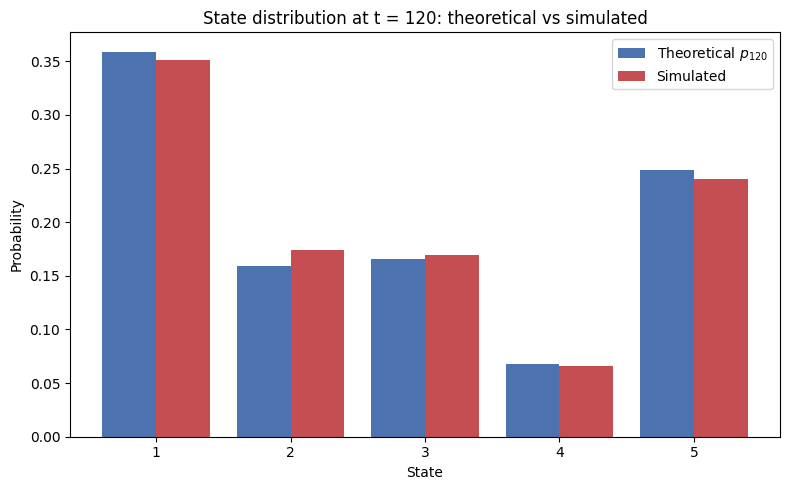

In [8]:
states = np.arange(1, 6)
width = 0.4
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(states - width/2, p_theory, width, label="Theoretical $p_{120}$", color="#4C72B0")
ax.bar(states + width/2, p_sim,    width, label="Simulated",            color="#C44E52")
ax.set_xticks(states)
ax.set_xlabel("State")
ax.set_ylabel("Probability")
ax.set_title(f"State distribution at t = {T}: theoretical vs simulated")
ax.legend()
plt.tight_layout()
plt.show()

### Conclusion (Task 2)

The simulated state distribution at $t = 120$ closely matches the analytic distribution
$p_0 P^{120}$, and the $\chi^2$ goodness-of-fit test gives a large $p$-value (we fail to reject
$H_0$). This validates the simulation at this time point. A passing test does not *prove* the
simulation is correct — it only fails to detect a discrepancy — but together with the matching
distribution it gives good confidence that the simulator behaves as intended.